In [1]:
%matplotlib inline
from collections import OrderedDict, defaultdict
import importlib.resources
import os.path
import pathlib
import warnings

import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u
from astropy.io import fits
from astropy.table import Table, vstack
from astropy.wcs import WCS
from scipy.special import erf

import scopesim as sim
from scopesim.utils import from_currsys
import scopesim_templates as sim_tp

In [2]:
from zs_scopesim_tools.helpers import (
    configure_path_and_logging,
    disable_scopesim_top_level_catch,
    validation_work_dir,
    warning_prevent_sync_alt_ra_dec,
    zshooter_package_dir,
)
from zs_scopesim_tools.sources import (
    ab_magnitude_flat,
    constant_photon_flux_flat,
    lamp_flat,
)
from zs_scopesim_tools.validation import (
    build_emissivity_sanity_data,
    build_transmission_sanity_data,
    detector_geometry_table,
    detector_selector_matrix,
    fetch_effect_spectrum_or_transmission,
    fov_image_plane_counts,
    get_effect,
    plot_emissivity_sanity,
    plot_source,
    plot_transmission_sanity,
    trace_catalog_table,
    validate_emissivity_sanity_data,
    validate_transmission_sanity_data,
)


## Configure IRDB Path and log level

In [3]:
irdb_path = configure_path_and_logging(irdb_path="/Users/jibailey/src/irdb", level="debug")
zshooter_dir = zshooter_package_dir(irdb_path)
output_dir = validation_work_dir(irdb_path)
disable_scopesim_top_level_catch()
cmd = sim.UserCommands(use_instrument="ZShooter_v2", set_modes=["SPEC"])
warning_prevent_sync_alt_ra_dec(cmd)
zs = sim.OpticalTrain(cmd)
print(f"Validation outputs: {output_dir}")


astar.scopesim.utils - Using !OBS.brightness dark for observation time
astar.scopesim.utils - WARNING: Obstime is not after sunset!
astar.scopesim.utils - Setting obstime to midnight of the same day. New UTC time is 2026-06-15T10:21:53.856.
astar.scopesim.utils - WARNING: Target coord !OBS.alt not set in !OBS config.
astar.scopesim.utils - WARNING: Target coord !OBS.ra not set in !OBS config.
astar.scopesim.utils - WARNING: Target coord !OBS.dec not set in !OBS config.
astar.scopesim.utils - Setting coordinates from alt/airmass, location and obstime input.
astar.scopesim.utils - Using !OBS.brightness dark for observation time
astar.scopesim.utils - WARNING: Obstime is not after sunset!
astar.scopesim.utils - Setting obstime to midnight of the same day. New UTC time is 2026-06-15T10:21:53.856.
astar.scopesim.utils - Setting coordinates from ra/dec input.
astar.scopesim.utils - ra/dec in str, assuming hourangle/degree units.
astar.scopesim.effects.sky_ter_curves - WARNING: wmin 299.99999

## Create the simulator and configure it


In [4]:
print(cmd)

CurrSys contents:
├─OBS:
│ ├─instrument: ZShooter_v2
│ ├─modes: ['SPEC']
│ ├─pupil_angle: 0
│ ├─object: Test
│ ├─az: 0.0
│ ├─airmass: 1.0
│ ├─seeing: 0.7
│ ├─brightness: dark
│ ├─dit_blue: 300.0
│ ├─ndit_blue: 1
│ ├─dit_green: 300.0
│ ├─ndit_green: 1
│ ├─dit_red: 300.0
│ ├─ndit_red: 1
│ ├─dit_yj: 300.0
│ ├─ndit_yj: 1
│ ├─dit_h: 300.0
│ ├─ndit_h: 1
│ ├─dit_k: 300.0
│ ├─ndit_k: 1
│ ├─alt: 90.0
│ ├─ra: 263d23m40.88042649s
│ └─dec: -1d57m37.02585573s
├─ATMO:
│ ├─background:
│ │ ├─filter_name: R
│ │ ├─value: 22.0
│ │ └─unit: mag
│ ├─location: MaunaKea
│ ├─altitude: 4123
│ ├─longitude: -155.4744
│ ├─latitude: 19.8263
│ ├─temperature: 2.5
│ ├─humidity: 0.1
│ ├─pressure: 0.62
│ ├─pwv: 2.5
│ ├─x_co2: 450
│ ├─airmass: !OBS.airmass
│ ├─pupil_angle: !OBS.pupil_angle
│ ├─pixel_scale: !INST.pixel_scale
│ └─seeing: !OBS.seeing
├─TEL:
│ ├─telescope: keck
│ └─temperature: !ATMO.temperature
├─INST:
│ ├─temperature: -80
│ ├─pixel_scale: 0.159574468085
│ ├─plate_scale: 10.638297872333334
│ ├─decouple_dete

Check that FoV's are defined as expected. The trace catalog is taken from the in-memory `trace_list_analytical` effect loaded into this `OpticalTrain`, then compared to the FoV image-plane split.

In [5]:
trace_list = get_effect(zs, "trace_list_analytical")
ecat = trace_catalog_table(trace_list)
display(ecat)
print(f"Trace list contains {len(ecat)} traces.")
print(f"Number of traces per image plane: {np.unique(list(ecat['image_plane_id']), return_counts=True)}")


trace_id,aperture_id,image_plane_id,extension_id,wave_min_um,wave_max_um
str5,int64,int64,int64,float64,float64
b_66,0,0,2,0.41758672893069787,0.43056975631352107
b_67,0,0,3,0.41135409118546357,0.4241433420401849
b_68,0,0,4,0.40530476631508916,0.41790593995135866
b_69,0,0,5,0.39943078419458056,0.41184933212597663
b_70,0,0,6,0.393724630134658,0.4059657702384627
b_71,0,0,7,0.3881792128088178,0.4002479424886252
b_72,0,0,8,0.3827878348531397,0.3946889432873943
b_73,0,0,9,0.37754416588254874,0.38928224543414236
b_74,0,0,10,0.37244221769494673,0.3840216745498971


Trace list contains 120 traces.
Number of traces per image plane: (array([0, 1, 2, 3, 4, 5]), array([26, 26, 22, 25, 12,  9]))


In [6]:
display(fov_image_plane_counts(zs))
# It is ok if some are off by one, those are traces at the edgees that get cutoff by the dichroic settings.

astar.scopesim.optics.fov_manager - Returning existing fovs_list.


image_plane_id,n_fovs
int64,int64
0,26
1,26
2,22
3,25
4,12
5,9


## Tweak what effects are included if desired

In [7]:
zs.effects

element,name,class,included
str15,str31,str25,bool
MaunaKea,atmo_transmission,TERCurve,True
MaunaKea,continuum_emission,SkyBackgroundTERCurve,True
MaunaKea,airglow_and_interline_continuum,PalaceAirglowEmission,True
MaunaKea,seeing_psf,AOEnhanceablePSF,True
MaunaKea,adc_residuals,ADCShift,True
keck,telescope_reflection,SurfaceList,True
ZShooter,dichroic_tree,DichroicTree,True
ZShooter,slitwheel_selector,SelectorWheel,True
ZShooter,channel_optics_selector,SelectorWheel,True


In [8]:
#zs['adc'].include = False

## Transmission Curves Sanity Check

This plot derives the active throughput components from the constructed optical train. It follows ScopeSim's internal objects directly: dichroic branches from `DichroicTree`, grouped optics from the selected `SurfaceList`, detector QE from `detector_qe_selector`, and bundled echelle/cross-disperser order efficiencies from `trace_eff_analytical`.


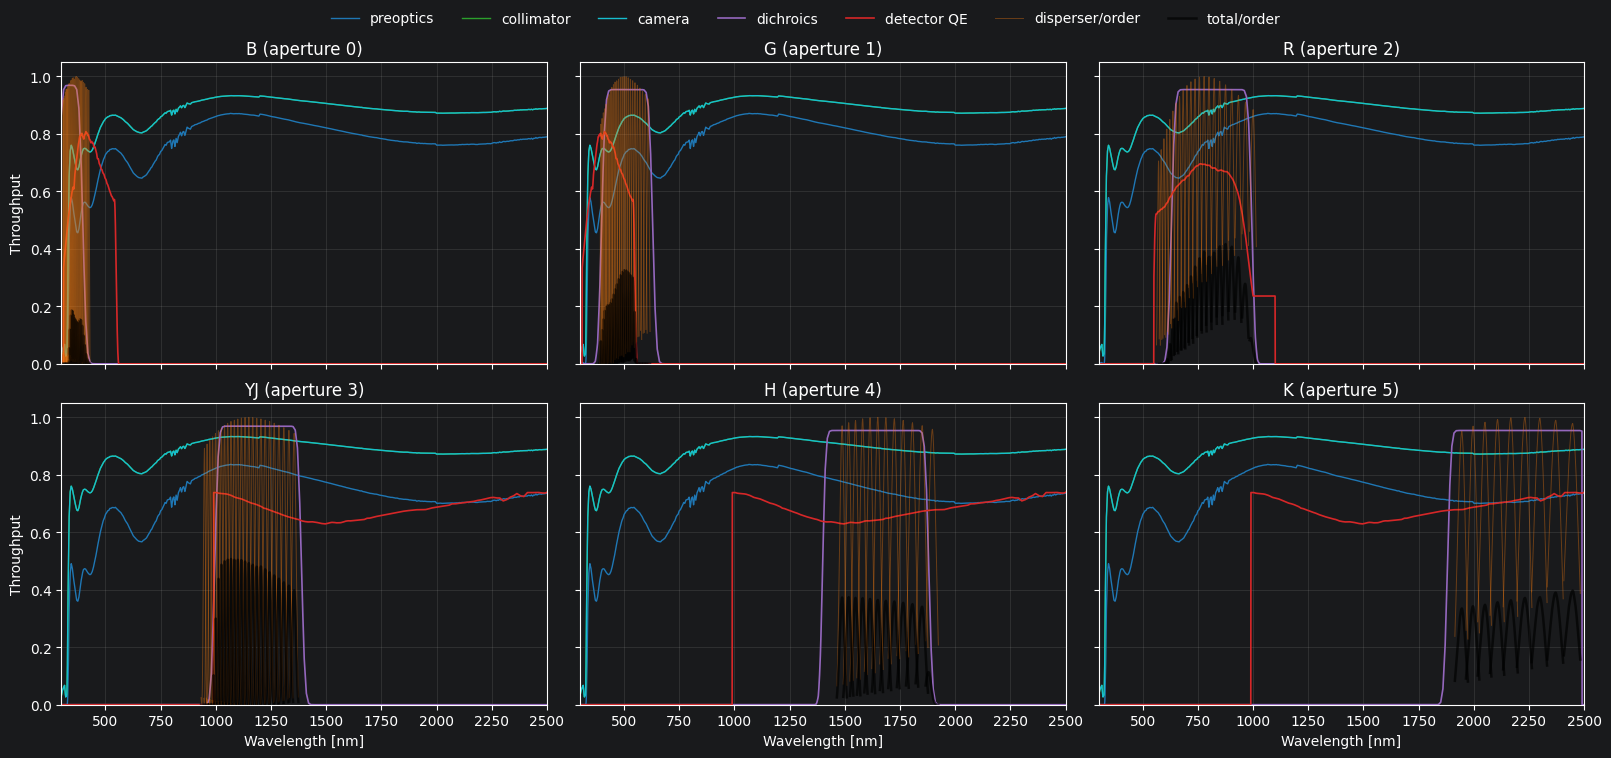

In [9]:
wave_nm = np.linspace(300, 2500, 5000) * u.nm
transmission_data = build_transmission_sanity_data(zs, wave_nm=wave_nm)
validate_transmission_sanity_data(transmission_data)
fig, axes = plot_transmission_sanity(transmission_data)


## Emissivity Check

This plot uses the active optical train and explicit `throughput_group` / `emission_phase` metadata from the ZShooter optics lists. Pre-disperser optics are shown as the terms that should still pass through trace mapping; post-disperser camera terms are shown after detector QE, which is the candidate diffuse image-plane background. Detector QE is plotted as throughput only, not as detector emissivity.


surface,group,emission_phase,action,temperature,emissivity_source,transmission_source,reflection_source,qe_applied,peak_output_emissivity,peak_after_qe,aperture_id,channel
str20,str11,str15,str12,object,str26,str24,str26,bool,float64,float64,int64,str2
VIS_Fold,preoptics,pre_disperser,reflection,0,inferred from reflection,inferred from reflection,explicit,False,0.018867668207882535,0.018867668207882535,0,B
VIS_PreOptFirst,preoptics,pre_disperser,transmission,0,inferred from transmission,explicit,inferred from transmission,False,0.019887796517322243,0.019887796517322243,0,B
VIS_ADC_12,preoptics,pre_disperser,transmission,0,inferred from transmission,explicit,inferred from transmission,False,0.02102453391018346,0.02102453391018346,0,B
VIS_ADC_34,preoptics,pre_disperser,transmission,0,inferred from transmission,explicit,inferred from transmission,False,0.02229913716621199,0.02229913716621199,0,B
VIS_Derotator_AR_1,preoptics,pre_disperser,transmission,0,inferred from transmission,explicit,inferred from transmission,False,0.023738260886492557,0.023738260886492557,0,B
VIS_Derotator_AR_2,preoptics,pre_disperser,transmission,0,inferred from transmission,explicit,inferred from transmission,False,0.02537602616178766,0.02537602616178766,0,B
VIS_Derotator_Refl_1,preoptics,pre_disperser,reflection,0,inferred from reflection,inferred from reflection,explicit,False,0.027256476215346766,0.027256476215346766,0,B
VIS_Derotator_Refl_2,preoptics,pre_disperser,reflection,0,inferred from reflection,inferred from reflection,explicit,False,0.02943820156237265,0.02943820156237265,0,B
VIS_Derotator_Refl_3,preoptics,pre_disperser,reflection,0,inferred from reflection,inferred from reflection,explicit,False,0.031998930720169266,0.031998930720169266,0,B


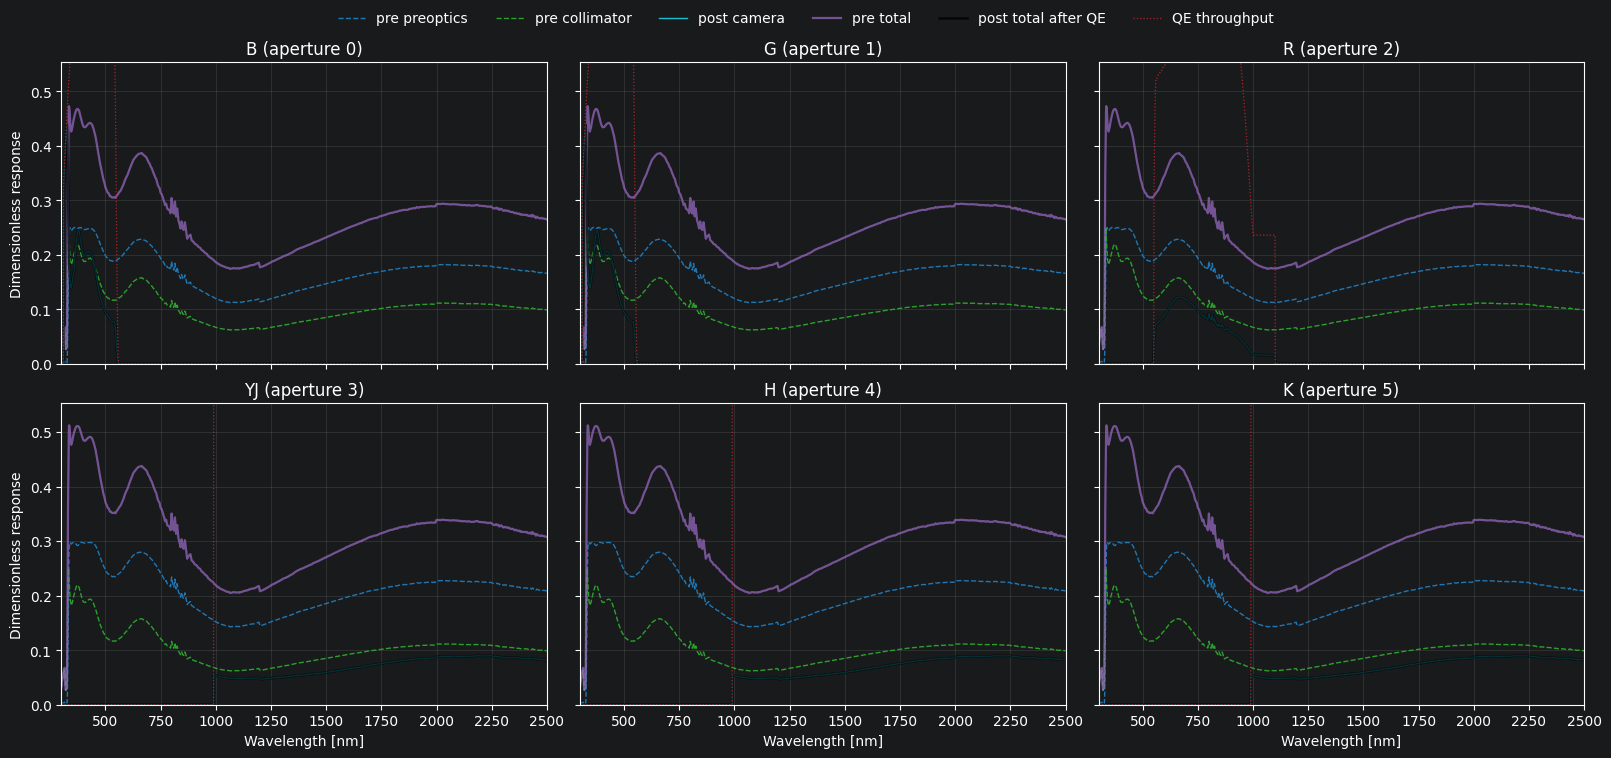

In [10]:
emissivity_data = build_emissivity_sanity_data(zs, wave_nm=wave_nm)
validate_emissivity_sanity_data(emissivity_data)
fig, axes = plot_emissivity_sanity(emissivity_data)
emissivity_data["details"]


## Detector Settings Sanity Check

In [11]:
detector_geometry = detector_geometry_table(zs)
detector_settings = detector_selector_matrix(zs)
display(detector_geometry)
display(detector_settings)


detector_id,image_plane_id,channel,detector,x_size,y_size,pixel_size_mm,gain_e_per_adu
int64,int64,str2,str6,int64,int64,float64,float64
0,0,B,CCD_B,2048,2048,0.015,1.0
1,1,G,CCD_G,2048,2048,0.015,1.0
2,2,R,CCD_R,2048,2048,0.015,1.0
3,3,YJ,APD_YJ,2048,2048,0.015,1.0
4,4,H,APD_H,2048,2048,0.015,1.0
5,5,K,APD_K,2048,2048,0.015,1.0


detector_id,channel,detector,selector,selector_key,selector_value,effect_class,settings
int64,str2,str6,str29,str11,int64,str25,str45
0,B,CCD_B,slitwheel_selector,aperture_id,0,SlitWheel,filename=None
0,B,CCD_B,channel_optics_selector,aperture_id,0,SurfaceList,filename=optics/LIST_zspec_vis_optics.dat
0,B,CCD_B,detector_qe_selector,aperture_id,0,SpectralQuantumEfficiency,filename=detector_specs/CCD_B_TER.dat
0,B,CCD_B,exposure_integration_selector,detector_id,0,ExposureIntegration,"filename=None, dit=300.0, ndit=1"
0,B,CCD_B,dark_current_selector,detector_id,0,DarkCurrent,"filename=None, dit=300.0, ndit=1, value=1e-05"
0,B,CCD_B,readout_noise_selector,detector_id,0,BasicReadoutNoise,"filename=None, ndit=1, noise_std=0.1"
0,B,CCD_B,visible_binning_selector,detector_id,0,UnequalBinnedImage,"filename=None, binx=1, biny=1"
0,B,CCD_B,bias_selector,detector_id,0,Bias,"filename=None, bias=1040"
1,G,CCD_G,slitwheel_selector,aperture_id,1,SlitWheel,filename=None


Now look at the actual values for this configuration

In [12]:
# - Report total variance for est exposure time + binning + ndit and component proportion (%dark, %read) and anchor relative to sky in both a fiducial patch and with the current slit

## Sky Flux sanity check

In [13]:
cmd['!OBS.brightness'] = 'bright'    # Sky brightness (bright/gray/dark)

# TODO reinit whatever needs reiniting

In [14]:
# Load the effect instances for the different sky background components
# Get emission arrays for each component
wave_th, flux_th = fetch_effect_spectrum_or_transmission(zs, "atmo_transmission", "emission")
wave_cont, flux_cont = fetch_effect_spectrum_or_transmission(zs, "continuum_emission", "emission")
wave_line, flux_line = fetch_effect_spectrum_or_transmission(zs, "airglow_and_interline_continuum", "line_TER.emission")
wave_res, flux_res = fetch_effect_spectrum_or_transmission(zs, "airglow_and_interline_continuum", "continuum_TER.emission")

# simple resample all to a common wavelength grid for plotting
common_wave = np.linspace(0.3, 2.5, 10001) * u.um
from scipy.interpolate import CubicSpline
from synphot.units import convert_flux

flux_th_interp = CubicSpline(wave_th, flux_th)(common_wave)
flux_cont_interp = CubicSpline(wave_cont, flux_cont)(common_wave)
flux_line_interp = CubicSpline(wave_line, flux_line)(common_wave)
flux_res_interp = CubicSpline(wave_res, flux_res)(common_wave)

# convert to AB mag for plotting
flux_th_erg = convert_flux(wavelengths=common_wave, fluxes=flux_th_interp, out_flux_unit="abmag")
flux_cont_erg = convert_flux(wavelengths=common_wave, fluxes=flux_cont_interp, out_flux_unit="abmag")
flux_line_erg = convert_flux(wavelengths=common_wave, fluxes=flux_line_interp, out_flux_unit="abmag")
flux_res_erg = convert_flux(wavelengths=common_wave, fluxes=flux_res_interp, out_flux_unit="abmag")


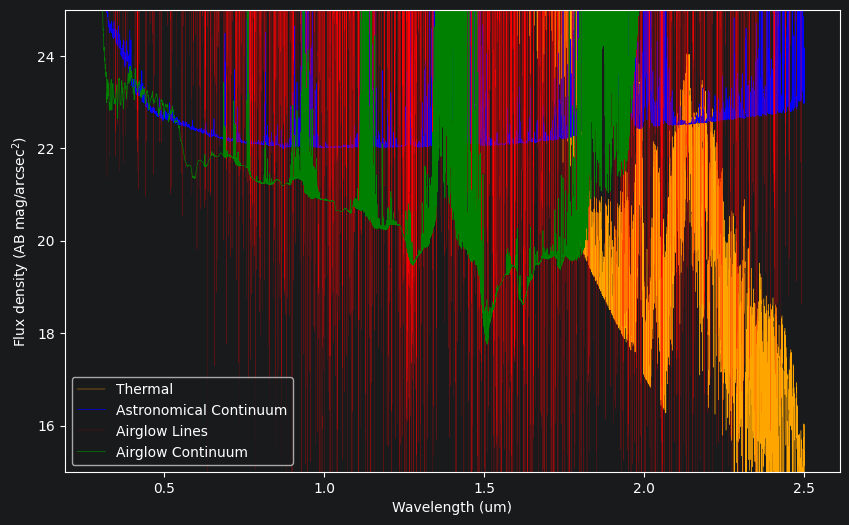

In [15]:
# plot
plt.figure(figsize=(10, 6))
plt.plot(common_wave, flux_th_erg, label='Thermal', color='orange', lw=0.3)
plt.plot(common_wave, flux_cont_erg, label='Astronomical Continuum', color='blue', lw=0.5)
plt.plot(common_wave, flux_line_erg, label='Airglow Lines', color='red', lw=0.1)
plt.plot(common_wave, flux_res_erg, label='Airglow Continuum', color='green', lw=0.5)
plt.xlabel("Wavelength (um)")
plt.ylabel(r"Flux density (AB mag/arcsec$^2$)")
plt.legend()
plt.ylim(15,25)
plt.show()

# Make and plot sources

(<Figure size 600x200 with 2 Axes>,
 array([[<Axes: title={'center': 'Spatial Profile'}>,
         <Axes: title={'center': 'Spectrum'}>]], dtype=object))

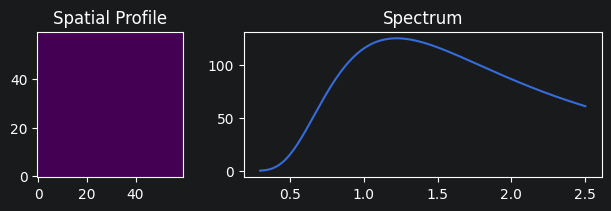

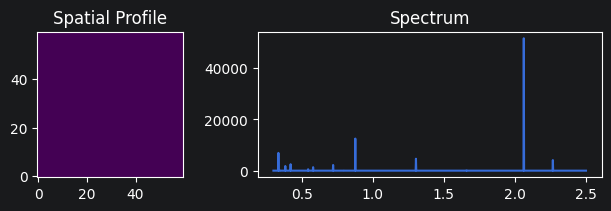

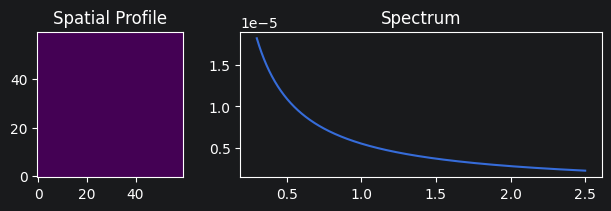

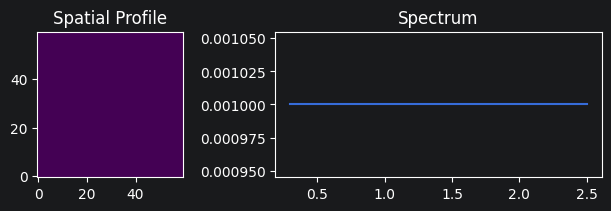

In [16]:
# Fetch a SN1a from spextra library
from spextra import Spextrum
from scopesim.source.source import Source

# SN1a point source
sn1a_source = Source(spectra=Spextrum('sne/sn1a').redshift(0.02).scale_to_magnitude(14*u.ABmag, 'g'), y=[2.5])

# Start point source
star_source = sim_tp.star('V', 23*u.ABmag, spec_type="A0V", x=[0], y=[0], library="pyckles")

# Calibration extended sources
quartz_flat = sim_tp.calibration.flat_field(temperature=3000*u.K, amplitude=4*u.ABmag, filter_curve='V', extend=60)
plot_source(quartz_flat)

lamp_flat_source = lamp_flat(zshooter_dir=zshooter_dir)
plot_source(lamp_flat_source)

# Uniformly source with const AB mag
uniform_flat_source = ab_magnitude_flat(mag=20, extent=60)
plot_source(uniform_flat_source)

# Uniformly illuminated source with a const photon flux density of 1 photon/s/cm^2/Angstrom
flat2 = constant_photon_flux_flat(amplitude=0.001, extent=60)
plot_source(flat2)


## Simulate it!

In [17]:
cmd['!OBS.airmass'] = 1.3            # Target coordinate information (other similar properties include: alt, az, ra, dec)
cmd['!OBS.seeing'] = 0.6            # Atmospheric seeing in arcsec (other similar properties include: pwv, humidity, temperature, pressure etc.)
cmd['!OBS.brightness'] = 'grey'    # Sky brightness (bright/gray/dark), !OBS.mjdobs takes precedence, call sky_band_prightness(<level>) to see what this means in band averages.
cmd['!OBS.dit'] = 300                 # Detector integration time in seconds for all detectors
cmd['!OBS.dit_green'] = 150                 # Detector integration time green channel, as demo
cmd['!OBS.ndit'] = 2                 # Number of exposures
cmd['!INST.vis_curr_slit'] = .7  # Slit width
cmd['!INST.nir_curr_slit'] = .7  # Slit width TODO change name

zs.observe(flat2) ## observes empty sky if no source is given

astar.scopesim.optics.fov_manager - Generating initial fovs_list.
astar.scopesim.effects.ter_curves - Executing dichroic_tree, FoV setup
astar.scopesim.effects.ter_curves - Created 1 FoVs for aperture_id 0
astar.scopesim.effects.ter_curves - Created 1 FoVs for aperture_id 1
astar.scopesim.effects.ter_curves - Created 1 FoVs for aperture_id 2
astar.scopesim.effects.ter_curves - Created 1 FoVs for aperture_id 3
astar.scopesim.effects.ter_curves - Created 1 FoVs for aperture_id 4
astar.scopesim.effects.ter_curves - Created 1 FoVs for aperture_id 5
astar.scopesim.effects.selector_wheel - Applying effect for aperture_id: 0 -> SlitWheel: "<empty> : [0.7]", volumes: 1
astar.scopesim.effects.apertures - Executing 0.7, FoV setup
astar.scopesim.effects.selector_wheel - Applying effect for aperture_id: 1 -> SlitWheel: "<empty> : [0.7]", volumes: 1
astar.scopesim.effects.apertures - Executing 0.7, FoV setup
astar.scopesim.effects.selector_wheel - Applying effect for aperture_id: 2 -> SlitWheel: "<

 FOVs:   0%|          | 0/120 [00:00<?, ?it/s]

astar.scopesim.optics.fov - 6 fields in FOV
astar.scopesim.optics.fov - old naxis: [60, 60]
astar.scopesim.optics.fov - Found 'deg' in image WCS, applying 360 fix.
astar.scopesim.optics.fov - XY HDU:
[[ 0.00833333 -0.00833333]
 [ 0.00833333  0.00833333]
 [-0.00833333  0.00833333]
 [-0.00833333 -0.00833333]]
astar.scopesim.optics.fov - XY FOV:
[[-1.40366430e-03 -8.00827423e-05]
 [-1.40366430e-03  9.72222222e-05]
 [ 1.38888889e-03  9.72222222e-05]
 [ 1.38888889e-03 -8.00827423e-05]]
astar.scopesim.optics.fov - xy0s: [-1.40366430e-03 -8.00827423e-05]; xy1s: [1.38888889e-03 9.72222222e-05]
astar.scopesim.optics.fov - xyp:
[[34.5531915 29.2117021]
 [24.5       29.85     ]]
astar.scopesim.optics.fov - xyp:
[[24.5       29.2117021]
 [34.5531915 29.85     ]]
astar.scopesim.optics.fov - xy0p: [24 29]; xy1p: [35 30]
astar.scopesim.optics.fov - xy0p: [24 29]; xy1p: [35 30]


 FOV effects:   0%|          | 0/8 [00:00<?, ?it/s]

astar.scopesim.effects.psfs.psf_base - Executing seeing_psf, convolution
astar.scopesim.effects.psfs.analytical - WARNING: Kernel size too small, kernel sums to 0.9767626382005072
astar.scopesim.effects.psfs.psf_base - PSF convolution start
astar.scopesim.effects.psfs.psf_base - PSF convolution done
astar.scopesim.effects.atmo_dispersion - Residuals supplied by adc_residuals.dat
astar.scopesim.effects.atmo_dispersion - Additional residual from zenith angle error: 0.1
astar.scopesim.utils - Using !OBS.brightness dark for observation time
astar.scopesim.utils - WARNING: Obstime is not after sunset!
astar.scopesim.utils - Setting obstime to midnight of the same day. New UTC time is 2026-06-15T10:21:53.856.
astar.scopesim.utils - Setting coordinates from ra/dec input.
astar.scopesim.utils - ra/dec in str, assuming hourangle/degree units.
astar.scopesim.effects.atmo_dispersion - Direction of zenith, measured counter-clockwise from +y axis is 179.
astar.scopesim.effects.ter_curves - Executin

...

astar.scopesim.effects.psfs.psf_base - Executing seeing_psf, convolution
astar.scopesim.effects.psfs.psf_base - PSF convolution start
astar.scopesim.effects.psfs.psf_base - PSF convolution done
astar.scopesim.effects.atmo_dispersion - Residuals supplied by adc_residuals.dat
astar.scopesim.effects.atmo_dispersion - Additional residual from zenith angle error: 0.1
astar.scopesim.utils - Using !OBS.brightness dark for observation time
astar.scopesim.utils - WARNING: Obstime is not after sunset!
astar.scopesim.utils - Setting obstime to midnight of the same day. New UTC time is 2026-06-15T10:21:53.856.
astar.scopesim.utils - Setting coordinates from ra/dec input.
astar.scopesim.utils - ra/dec in str, assuming hourangle/degree units.
astar.scopesim.effects.atmo_dispersion - Direction of zenith, measured counter-clockwise from +y axis is 179.
astar.scopesim.effects.ter_curves - Executing dichroic_tree, observe
astar.scopesim.effects.spectral_trace_list - trace_list_analytical applied to Fiel

 FOV effects:   0%|          | 0/8 [00:00<?, ?it/s]

astar.scopesim.effects.psfs.psf_base - Executing seeing_psf, convolution
astar.scopesim.effects.psfs.psf_base - PSF convolution start
astar.scopesim.effects.psfs.psf_base - PSF convolution done
astar.scopesim.effects.atmo_dispersion - Residuals supplied by adc_residuals.dat
astar.scopesim.effects.atmo_dispersion - Additional residual from zenith angle error: 0.1
astar.scopesim.utils - Using !OBS.brightness dark for observation time
astar.scopesim.utils - WARNING: Obstime is not after sunset!
astar.scopesim.utils - Setting obstime to midnight of the same day. New UTC time is 2026-06-15T10:21:53.856.
astar.scopesim.utils - Setting coordinates from ra/dec input.
astar.scopesim.utils - ra/dec in str, assuming hourangle/degree units.
astar.scopesim.effects.atmo_dispersion - Direction of zenith, measured counter-clockwise from +y axis is 179.
astar.scopesim.effects.ter_curves - Executing dichroic_tree, observe
astar.scopesim.effects.spectral_trace_list - trace_list_analytical applied to Fiel

 FOV effects:   0%|          | 0/8 [00:00<?, ?it/s]

astar.scopesim.effects.psfs.psf_base - Executing seeing_psf, convolution
astar.scopesim.effects.psfs.psf_base - PSF convolution start
astar.scopesim.effects.psfs.psf_base - PSF convolution done
astar.scopesim.effects.atmo_dispersion - Residuals supplied by adc_residuals.dat
astar.scopesim.effects.atmo_dispersion - Additional residual from zenith angle error: 0.1
astar.scopesim.utils - Using !OBS.brightness dark for observation time
astar.scopesim.utils - WARNING: Obstime is not after sunset!
astar.scopesim.utils - Setting obstime to midnight of the same day. New UTC time is 2026-06-15T10:21:53.856.
astar.scopesim.utils - Setting coordinates from ra/dec input.
astar.scopesim.utils - ra/dec in str, assuming hourangle/degree units.
astar.scopesim.effects.atmo_dispersion - Direction of zenith, measured counter-clockwise from +y axis is 179.
astar.scopesim.effects.ter_curves - Executing dichroic_tree, observe
astar.scopesim.effects.spectral_trace_list - trace_list_analytical applied to Fiel

#### Read it out

In [18]:
hdul = zs.readout()

astar.scopesim.optics.optical_train - exptime: None given in kwargs, put in !OBS
astar.scopesim.optics.optical_train - dit: None given in kwargs, put in !OBS
astar.scopesim.optics.optical_train - ndit: None given in kwargs, put in !OBS
astar.scopesim.detector.detector_manager - Extracting from 1 detectors...
astar.scopesim.effects.selector_wheel - Since passed object is a Detector, selector_key by default is the ID of the Detector object.
astar.scopesim.effects.electronic - ExposureIntegration.: DIT = 300.0 s, NDIT = 1
astar.scopesim.effects.selector_wheel - Since passed object is a Detector, selector_key by default is the ID of the Detector object.
astar.scopesim.effects.selector_wheel - Since passed object is a Detector, selector_key by default is the ID of the Detector object.
astar.scopesim.effects.selector_wheel - Since passed object is a Detector, selector_key by default is the ID of the Detector object.
astar.scopesim.effects.selector_wheel - Since passed object is a Detector, s

## Show it

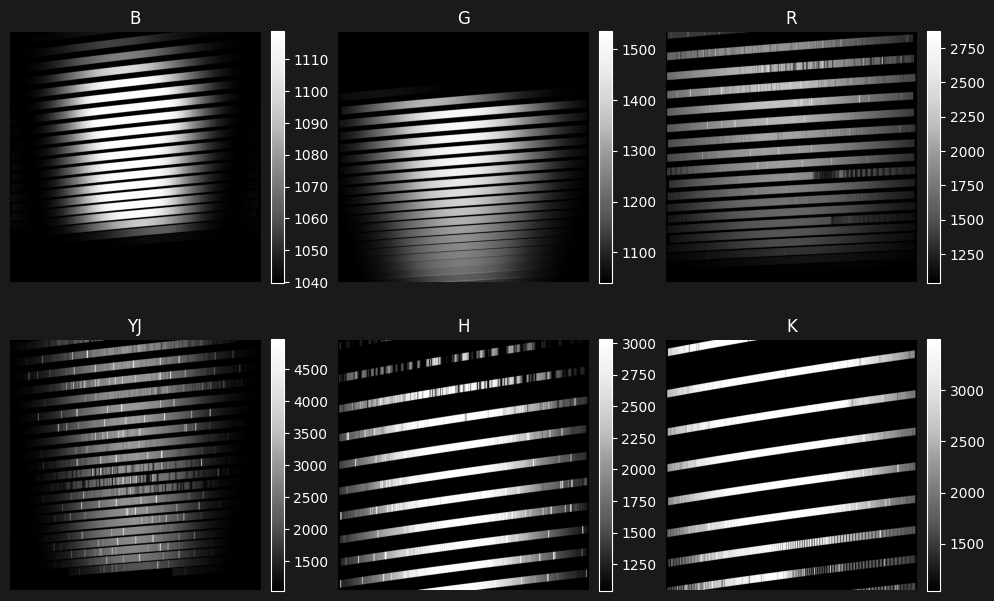

In [19]:
from astropy.visualization import ZScaleInterval

# reduce space between subplots
fig, axes = plt.subplots(2,3, figsize=(12,8), gridspec_kw={'wspace':0.2}, tight_layout=True)
titles = ['B', 'G', 'R', 'YJ', 'H', 'K']
for i, (ax, imhdu) in enumerate(zip(axes.flat, hdul)):
    interval = ZScaleInterval()
    vmin, vmax = interval.get_limits(imhdu[1].data)
    ax.axis("off")
    im = ax.imshow(imhdu[1].data, origin='lower', vmin=vmin, vmax=vmax, cmap='Grays_r')
    ax.set_title(titles[i])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.subplots_adjust(wspace=0.0, hspace=0.0)
fig.savefig(output_dir / "zspec_echellogram.png", dpi=300)

for title, channel_hdul in zip(titles, hdul):
    channel_hdul.writeto(output_dir / f"zspec_{title}.fits", overwrite=True)
